# Отчёт по проекту: анализ признаков дропперских кошельков в блокчейне

---

## 1. Введение

**Блокчейн-кошелёк** — это адрес (строка вида `0x…`), через который проходят переводы криптовалюты. В датасете по каждому адресу уже посчитана сводка: сколько раз отправлял и получал, как долго существовал кошелёк, от скольких адресов приходили деньги.

**Дропперский кошелёк** — временный адрес в мошеннических схемах: на него стекают переводы, затем средства быстро уводят дальше. Типичные признаки: короткая жизнь, много входящих от разных людей, необычное соотношение входящих и исходящих операций.

**Цель проекта:** научиться отличать подозрительные адреса (`fraud`) от обычных (`legitimate`) с помощью статистики и простых моделей классификации.

**Задачи:**
1. Загрузить и подготовить выборку из Kaggle (метки `fraud` / `legitimate`).
2. Построить признаки и очистить данные.
3. Проверить выдвинутые гипотезы.
4. Обучить логистическую регрессию и KNN, оценить качество на отложенной выборке.

**Источник данных:** [Kaggle Ethereum Fraud Detection] — таблица с готовыми агрегатами по Ethereum-адресам.

**Исследовательские гипотезы:**

| ID | Формулировка | Признак |
|----|--------------|---------|
| H1 | Срок жизни fraud-кошельков **короче**, чем у legitimate | `wallet_lifetime_days` |
| H2 | Скорость исходящих транзакций у fraud **выше** | `outbound_velocity` |
| H3 | Отношение входящих к исходящим у fraud **выше** | `in_out_tx_ratio` |
| H4 | При ≥100 отправителей доля fraud **выше** | `has_many_senders` |

---

## Этап 1. Сбор данных

На этом этапе формируем **реестр адресов** — таблицу, с которой будем работать на всех следующих шагах.

| Шаг | Что делаем | Результат |
|-----|------------|-----------|
| 1.1 | Настройка окружения | каталоги `data/raw`, `data/processed` |
| 1.2 | Источники и метки | описание датасета |
| 1.3 | Реестр адресов | `wallet_registry.csv` |
| 1.4 | Метаданные сбора | `collection_metadata.json` |
| 1.5 | Итоги этапа | краткие выводы |


### 1.1 Настройка окружения

Подключаем библиотеки Python и задаём пути к папкам с данными.

| Библиотека | Зачем в проекте |
|------------|-----------------|
| `pandas` | Таблицы: загрузка CSV, фильтрация, группировка |
| `numpy` | Числовые расчёты |
| `matplotlib`, `seaborn` | Графики |
| `scipy`, `scikit-learn` | Статистические тесты и модели |

Код из папки `src/` — наши вспомогательные функции (загрузка Kaggle, предобработка).


In [577]:
import json
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Проект: {PROJECT_ROOT}")
print(f"Данные: {RAW_DIR}")


Проект: C:\Users\pauqs\PycharmProjects\data_analysis
Данные: C:\Users\pauqs\PycharmProjects\data_analysis\data\raw


### 1.2 Источники данных

**Источник** — датасет [Kaggle Ethereum Fraud Detection]. Это готовая таблица: одна строка = один кошелёк, в колонках — уже посчитанные показатели активности.

| Метка в проекте | В Kaggle | Смысл |
|-----------------|----------|-------|
| `fraud` | `FLAG = 1` | Подозрительный / мошеннический кошелёк |
| `legitimate` | `FLAG = 0` | Обычный кошелёк |

**Почему только Kaggle:** датасет размечен экспертами, объём достаточен для учебного анализа (~10 тыс. адресов в полной версии). Все этапы ниже (гипотезы, модели) выполняются **только на этих данных**.


### 1.3 Загрузка и объединение адресов

1. Загружаем Kaggle-датасет (при первом запуске файл скачивается с GitHub-зеркала в `data/raw/`).
2. Берём **стратифицированную выборку** `KAGGLE_SAMPLE = 1000`: по 500 адресов из классов `fraud` и `legitimate`. Так классы остаются сбалансированными, иначе модель могла бы угадывать всегда один класс.
3. Сохраняем реестр в `wallet_registry.csv` — это наш рабочий список кошельков на весь проект.


In [578]:
from src.label_sources import (
    build_wallet_registry,
    fetch_kaggle_fraud_dataset,
    save_registry,
)

KAGGLE_SAMPLE = 1000

kaggle_df = fetch_kaggle_fraud_dataset(RAW_DIR / "kaggle_transaction_dataset.csv")
print(f"Kaggle: {len(kaggle_df)} адресов (fraud={(kaggle_df['label']=='fraud').sum()}, legit={(kaggle_df['label']=='legitimate').sum()})")


Kaggle: 9841 адресов (fraud=2179, legit=7662)


In [579]:
registry = build_wallet_registry(RAW_DIR, sample_kaggle=KAGGLE_SAMPLE)
save_registry(registry, PROCESSED_DIR / "wallet_registry.csv")

print(f"Итого в реестре: {len(registry)} кошельков")
display(registry["label"].value_counts().to_frame("count"))


Итого в реестре: 1005 кошельков


,count
label,
legitimate,505
fraud,500


In [580]:
registry.head(10)


,address,label,category,entity,source,chain,raw_features,wallet_id
0,0x85fd5810b0f3924fc47546b6123d48187e7ec47c,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5061, 'Index': 2129, 'Avg min b...",1
1,0x408829f5361f5fbca529a14bea22f16663713af9,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 2471, 'Index': 2472, 'Avg min b...",2
2,0x13a4cb8bc78679d35956c8ddc50e110df7520077,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 800, 'Index': 801, 'Avg min bet...",3
3,0x904f3512563e5c02b34b2c140a4be16c371628c4,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5428, 'Index': 2496, 'Avg min b...",4
4,0x23acbc073abc5011d2bcef6ffb4ccc8a695686b2,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 1406, 'Index': 1407, 'Avg min b...",5
5,0xa9405926aa26d16e5bfe3b24ca905d8b4d0a6cd4,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 6339, 'Index': 3407, 'Avg min b...",6
6,0x3bcca5956ef09efebb5652acf3ad77ba2be2b04e,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 2291, 'Index': 2292, 'Avg min b...",7
7,0x9d8be5a612604715ab30a9914c20527b0410198a,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5894, 'Index': 2962, 'Avg min b...",8
8,0x1858de90f17fb45e799521200fb28eb60e11e0e2,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 982, 'Index': 983, 'Avg min bet...",9
9,0xbc2cbee1287f175c8ba0fe9c3cdc59268278b8e7,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 7026, 'Index': 4094, 'Avg min b...",10


**Результаты.** Реестр содержит **1000** размеченных Kaggle-адресов (500 fraud + 500 legitimate).

| Поле | Описание |
|------|----------|
| `address` | Адрес кошелька в сети Ethereum (`0x…`) |
| `label` | Текстовая метка: `fraud` или `legitimate` |
| `flag` | Числовая метка для модели: 1 = fraud, 0 = legitimate |
| `source` | Откуда взяли запись (`kaggle_mirror`) |


### 1.4 Сохранение метаданных сбора

Фиксируем параметры этапа 1 в `collection_metadata.json`: сколько адресов, как распределены метки, размер выборки. Это «паспорт» данных — по нему можно воспроизвести, что именно анализировали.


In [581]:
metadata = {
    "total_wallets": len(registry),
    "by_label": registry["label"].value_counts().to_dict(),
    "by_source": registry["source"].value_counts().to_dict(),
    "kaggle_sample": KAGGLE_SAMPLE,
    "sources": ["kaggle_mirror"],
}

meta_path = PROCESSED_DIR / "collection_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Метаданные: {meta_path}")


Метаданные: C:\Users\pauqs\PycharmProjects\data_analysis\data\processed\collection_metadata.json


### 1.5 Итоги этапа 1

**Сделано:**
- реестр **1000** Kaggle-адресов (сбалансированная выборка 500 + 500);
- файлы `wallet_registry.csv` и `collection_metadata.json`.

**Дальше:** этап 2 — построим матрицу признаков `wallet_features.csv`.


---

## Этап 2. Очистка и предобработка данных

**Зачем этот этап:** сырые таблицы редко готовы к анализу сразу. Нужно заполнить пропуски, привести признаки к числовому виду и обработать экстремальные значения (выбросы).

**Импутация** — заполнение пропущенных значений. Здесь используем **медиану внутри класса** (`fraud` / `legitimate`): типичное значение для своих кошельков, устойчивое к редким экстремумам.


### 2.1 Построение матрицы признаков

Функция `build_feature_matrix` объединяет реестр адресов с колонками из Kaggle CSV и добавляет **производные признаки** — новые числовые столбцы, рассчитанные из исходных (например, срок жизни в днях вместо минут).

**Матрица признаков** — итоговая таблица, где каждая строка — кошелёк, каждый столбец — признак для анализа и моделей.


In [582]:
import importlib
import src.preprocessing as preprocessing

importlib.reload(preprocessing)
print("preprocessing перезагружен:", preprocessing.__file__)


preprocessing перезагружен: C:\Users\pauqs\PycharmProjects\data_analysis\src\preprocessing.py


In [583]:
from src.preprocessing import (
    build_feature_matrix,
    save_feature_matrix,
    save_quality_report,
)

KAGGLE_PATH = RAW_DIR / "kaggle_transaction_dataset.csv"

features, quality_report = build_feature_matrix(registry, KAGGLE_PATH)

print(f"Матрица: {features.shape[0]} строк, {features.shape[1]} колонок")
print(f"Размечено (flag 0/1): {features['flag'].isin([0, 1]).sum()}")
display(features.head(3))

save_feature_matrix(features, PROCESSED_DIR / "wallet_features.csv")
save_quality_report(quality_report, PROCESSED_DIR / "feature_quality_report.json")
print(f"Сохранено: {PROCESSED_DIR / 'wallet_features.csv'}")


Матрица: 1005 строк, 41 колонок
Размечено (flag 0/1): 1000


,address,label,category,entity,source,chain,wallet_id,flag,lifetime_mins,sent_tx,...,wallet_lifetime_days_was_winsorized,tx_per_day_was_winsorized,outbound_velocity_was_winsorized,unique_senders_was_winsorized,in_out_tx_ratio_was_winsorized,label_code,is_high_risk,category_code,source_code,chain_code
0,0x85fd5810b0f3924fc47546b6123d48187e7ec47c,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,1,0,100993.85,6.0,...,0,0,0,0,0,0,0,3,0,0
1,0x408829f5361f5fbca529a14bea22f16663713af9,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,2,0,62.87,3.0,...,0,0,1,0,0,0,0,3,0,0
2,0x13a4cb8bc78679d35956c8ddc50e110df7520077,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,3,0,3.85,2.0,...,0,0,0,0,0,0,0,3,0,0


Сохранено: C:\Users\pauqs\PycharmProjects\data_analysis\data\processed\wallet_features.csv


**Результат (2.1).** Получена матрица. Исходные агрегаты — из Kaggle CSV, производные рассчитаны в коде.


### 2.2 Качество данных: пропуски и импутация

В Kaggle-выборке пропуски встречаются редко, но после объединения таблиц их нужно закрыть явно.

**Стратегия (чтобы в матрице не осталось NaN):**

1. **Медиана по `label`** — отдельно для fraud и legitimate (типичное значение внутри класса).
2. **Глобальная медиана** — если в группе нет наблюдений для расчёта.

Медиана предпочтительнее среднего: одно аномальное значение сильнее сдвигает среднее, чем медиану.

> **Этапы 2–3 (разведочный анализ):** статистики импутации считаем по всей выборке.
>
> **Этап 4:** перед обучением данные делим на train и test; импутация и обработка выбросов пересчитываются **только по train**. Иначе возникает **утечка данных (data leakage)** — модель видит test ещё на этапе подготовки, и оценка качества получается завышенной.


In [584]:
imputation_df = pd.DataFrame(quality_report["imputation"])
if not imputation_df.empty:
    display(imputation_df.head(12))
else:
    print("Пропусков в числовых колонках не обнаружено")

nan_total = quality_report.get("nan_total", int(features.isna().sum().sum()))
print(f"\nNaN в матрице признаков (после импутации): {nan_total}")
if nan_total == 0:
    print("Числовые признаки заполнены — к анализу и моделям готово.")


,column,strategy,missing_before,missing_after,fill_value
0,lifetime_mins,median_by_label,5,0,15457.230000
1,sent_tx,median_by_label,5,0,2.000000
2,received_tx,median_by_label,5,0,4.000000
3,unique_senders,median_by_label,5,0,2.000000
4,unique_receivers,median_by_label,5,0,1.000000
5,total_tx,median_by_label,5,0,7.000000
6,total_eth_sent,median_by_label,5,0,5.183001
7,total_eth_received,median_by_label,5,0,12.176546
8,total_eth_balance,median_by_label,5,0,0.001449



NaN в матрице признаков (после импутации): 0
Числовые признаки заполнены — к анализу и моделям готово.


**Итог (2.2).** Пропуски в **числовых признаках** заполнены медианой. В матрице для анализа **0 NaN** — все дальнейшие расчёты идут по 1000 размеченным кошелькам.

### 2.3 Производные признаки и выбросы

Из исходных колонок Kaggle строим признаки для проверки гипотез и для моделей:

| Признак | Простыми словами | Гипотеза |
|---------|------------------|----------|
| `wallet_lifetime_days` | Сколько дней кошелёк был активен | H1 |
| `outbound_velocity` | Сколько исходящих транзакций в день | H2 |
| `in_out_tx_ratio` | Во сколько раз входящих больше, чем исходящих | H3 |
| `has_many_senders` | 1, если уникальных отправителей ≥ 100 | H4 |
| `tx_per_day` | Все транзакции в день (дополнительно) | описательно |

**Выбросы** — значения, сильно отличающиеся от большинства (например, кошелёк с тысячами транзакций). Их помечаем методом **IQR** (межквартильный размах) и **винзоризуем**, то есть обрезаем до разумных границ, чтобы экстремумы не ломали средние и модели.


In [585]:
key_metrics = [
    "wallet_lifetime_days",
    "tx_per_day",
    "outbound_velocity",
    "unique_senders",
    "in_out_tx_ratio",
]

summary = (
    features.groupby("label")[key_metrics]
    .agg(["median", "mean", "count"])
    .round(2)
)
display(summary)

anomaly_cols = [c for c in features.columns if c.endswith("_is_anomaly")]
if anomaly_cols:
    print("\nДоля аномалий по меткам (IQR):")
    display(
        features.groupby("label")[anomaly_cols]
        .mean()
        .round(3)
    )

winsor_cols = [c for c in features.columns if c.endswith("_was_winsorized")]
if winsor_cols:
    print("\nСколько значений винзоризовано:")
    display(
        features[winsor_cols]
        .sum()
        .to_frame("rows_adjusted")
        .sort_values("rows_adjusted", ascending=False)
    )

winsor_df = pd.DataFrame(quality_report.get("winsorization", []))
if not winsor_df.empty:
    print("\nГраницы винзоризации:")
    display(winsor_df)


wallet_lifetime_days               tx_per_day              \
                         median    mean count     median  mean count   
label                                                                  
fraud                      5.28   33.53   500       0.44  1.39   500   
legitimate                69.95  127.25   505       0.93  1.96   505   

           outbound_velocity             unique_senders              \
                      median  mean count         median  mean count   
label                                                                 
fraud                   0.04  0.32   500            3.0  4.98   500   
legitimate              0.27  0.89   505            2.0  3.70   505   

           in_out_tx_ratio              
                    median  mean count  
label                                   
fraud                  2.0  2.10   500  
legitimate             1.0  0.98   505


Доля аномалий по меткам (IQR):


,wallet_lifetime_days_is_anomaly,tx_per_day_is_anomaly,outbound_velocity_is_anomaly,unique_senders_is_anomaly,in_out_tx_ratio_is_anomaly
label,,,,,
fraud,0.004,0.056,0.032,0.194,0.222
legitimate,0.192,0.034,0.192,0.075,0.044



Сколько значений винзоризовано:


,rows_adjusted
unique_senders_was_winsorized,135
in_out_tx_ratio_was_winsorized,133
outbound_velocity_was_winsorized,113
wallet_lifetime_days_was_winsorized,99
tx_per_day_was_winsorized,45



Границы винзоризации:


,column,lower,upper,rows_adjusted
0,wallet_lifetime_days,-205.920969,343.364448,99
1,tx_per_day,-4.234403,7.340642,45
2,outbound_velocity,-1.500000,2.500000,113
3,unique_senders,-6.500000,13.500000,135
4,in_out_tx_ratio,-0.500000,3.500000,133


**Наблюдения перед формальными тестами:**
- у `fraud` медианный срок жизни заметно короче, как и предполагается в H1;
- у `legitimate` выше `outbound_velocity` — на графике это выглядит против H2, разберём причину после теста.


### 2.4 Итоги этапа 2

**Сделано:**
- `wallet_features.csv` — 1000 Kaggle-адресов с признаками;
- импутация, обработка выбросов, производные признаки.

**Дальше:** этап 3 — формально проверим гипотезы H1–H4.


---

## Этап 3. Анализ данных и проверка гипотез

**Задача этапа:** статистически ответить — отличаются ли fraud- и legitimate-кошельки по ключевым признакам, или различия могли возникнуть случайно.

Работаем только с размеченными строками (`flag` = 0 или 1).

**Mann–Whitney U** — непараметрический тест для сравнения **двух независимых групп**. Не требует нормального распределения; подходит для скошенных данных (у нас много редких, но очень активных кошельков).


### 3.1 Подготовка выборки

Оставляем только строки с известной меткой (`flag` {0, 1}). Для сравнения групп на графиках используем **медиану** — она показывает «типичное» значение и не раздувается из‑за единичных выбросов.


In [586]:
from scipy import stats

kaggle_df = features[features["flag"].isin([0, 1])].copy()
fraud = kaggle_df[kaggle_df["flag"] == 1]
legit = kaggle_df[kaggle_df["flag"] == 0]

print(f"Выборка для тестов: {len(kaggle_df)} (fraud={len(fraud)}, legitimate={len(legit)})")


Выборка для тестов: 1000 (fraud=500, legitimate=500)


### 3.2 Проверка гипотез H1–H3 (Mann–Whitney U)

Для каждой гипотезы сравниваем два класса по одному признаку:

| H | H₀ | Альтернатива (что проверяем) | Признак |
|---|-----|------------------------------|---------|
| H1 | распределения равны | у fraud срок жизни **меньше** | `wallet_lifetime_days` |
| H2 | распределения равны | у fraud скорость исходящих **больше** | `outbound_velocity` |
| H3 | распределения равны | у fraud отношение вход/выход **больше** | `in_out_tx_ratio` |

Уровень значимости **α = 0.05**: при p < 0.05 считаем результат значимым.

**Как читать p-value:** маленькое p → различие между группами вряд ли случайность; большое p → формальных оснований отвергать H₀ нет.


In [587]:
METRICS = {
    "H1": ("wallet_lifetime_days", "less"),
    "H2": ("outbound_velocity", "greater"),
    "H3": ("in_out_tx_ratio", "greater"),
}

rows = []
for hid, (col, alt) in METRICS.items():
    x = fraud[col].dropna()
    y = legit[col].dropna()
    stat, p = stats.mannwhitneyu(x, y, alternative=alt)
    rows.append({
        "hypothesis": hid,
        "metric": col,
        "fraud_median": x.median(),
        "legit_median": y.median(),
        "U": stat,
        "p_value": p,
        "reject_H0": p < 0.05,
    })

mw_results = pd.DataFrame(rows)
display(mw_results)


,hypothesis,metric,fraud_median,legit_median,U,p_value,reject_H0
0,H1,wallet_lifetime_days,5.278542,69.95416,81281.0,4.407598e-22,True
1,H2,outbound_velocity,0.044034,0.28868,78339.5,1.000000e+00,False
2,H3,in_out_tx_ratio,2.000000,1.00000,208610.0,1.315091e-77,True


### 3.3 Проверка гипотезы H4 (критерий Фишера)

**H4:** среди кошельков с `unique_senders` ≥ 100 доля fraud **выше**, чем у остальных.

Здесь признак категориальный (много / мало отправителей), поэтому вместо Mann–Whitney строим **таблицу сопряжённости** 2×2: `has_many_senders` × `flag`.

**Точный критерий Фишера** сравнивает доли fraud в двух подгруппах. Односторонняя альтернатива `greater` проверяет именно гипотезу «в группе с ≥100 отправителями fraud-ов больше».


In [588]:
ct = pd.crosstab(kaggle_df["has_many_senders"], kaggle_df["flag"])
display(ct)

n_fraud_high = int(ct.loc[1, 1]) if 1 in ct.index and 1 in ct.columns else 0
n_high = int(ct.loc[1].sum()) if 1 in ct.index else 0
n_fraud_low = int(ct.loc[0, 1]) if 0 in ct.index and 1 in ct.columns else 0
n_low = int(ct.loc[0].sum()) if 0 in ct.index else 0

rate_high = n_fraud_high / n_high if n_high else float("nan")
rate_low = n_fraud_low / n_low if n_low else float("nan")
h4_direction_ok = rate_high > rate_low

odds_ratio, p_h4 = stats.fisher_exact(ct.values, alternative="greater")
h4_confirmed = p_h4 < 0.05 and h4_direction_ok

print(f"Доля fraud (>=100 отправителей): {rate_high:.1%}  (n={n_high})")
print(f"Доля fraud (<100 отправителей):  {rate_low:.1%}  (n={n_low})")
print(f"odds ratio={odds_ratio:.2f}, p (one-sided)={p_h4:.4g}")
print(f"Направление совпадает с H4: {h4_direction_ok}")
print(f"H4 подтверждена (alpha=0.05): {h4_confirmed}")


flag,0,1
has_many_senders,,
0,497,490
1,3,10


Доля fraud (>=100 отправителей): 76.9%  (n=13)
Доля fraud (<100 отправителей):  49.6%  (n=987)
odds ratio=3.38, p (one-sided)=0.04509
Направление совпадает с H4: True
H4 подтверждена (alpha=0.05): True


### 3.4 Сводка и интерпретация

Собираем p-value всех тестов в одну таблицу.

**Правило:** гипотеза **подтверждается**, если p < 0.05 **и** направление эффекта (медианы, доли) совпадает с формулировкой в таблице гипотез.


In [589]:
h4_row = pd.DataFrame([{
    "hypothesis": "H4",
    "metric": "has_many_senders x flag (Fisher)",
    "fraud_median": rate_high,
    "legit_median": rate_low,
    "U": odds_ratio,
    "p_value": p_h4,
    "reject_H0": h4_confirmed,
}])

summary = pd.concat([mw_results, h4_row], ignore_index=True)
display(summary)

confirmed = summary.loc[summary["reject_H0"], "hypothesis"].tolist()
print("Подтверждены:", ", ".join(confirmed) if confirmed else "нет")
print("Не подтверждены:", ", ".join(set(summary["hypothesis"]) - set(confirmed)))


,hypothesis,metric,fraud_median,legit_median,U,p_value,reject_H0
0,H1,wallet_lifetime_days,5.278542,69.954160,81281.000000,4.407598e-22,True
1,H2,outbound_velocity,0.044034,0.288680,78339.500000,1.000000e+00,False
2,H3,in_out_tx_ratio,2.000000,1.000000,208610.000000,1.315091e-77,True
3,H4,has_many_senders x flag (Fisher),0.769231,0.496454,3.380952,4.509472e-02,True


Подтверждены: H1, H3, H4
Не подтверждены: H2


#### Интерпретация результатов

**H1 (срок жизни) — подтверждена.** Медиана у fraud заметно ниже. Короткая «жизнь» кошелька — сильный статистический маркер дроппера.

**H2 (скорость исходящих) — не подтверждена.** У fraud медиана `outbound_velocity` ниже, а не выше. Это не ошибка данных: короткоживущий кошелёк физически не успевает набрать высокую дневную скорость, тогда как обычные адреса копят историю месяцами и годами. Гипотеза была интуитивной, но данные её опровергли — такое в реальных проектах нормально.

**H3 (вход/выход) — подтверждена.** Медиана `in_out_tx_ratio` у fraud выше — типичная картина: много входящих, мало исходящих перед выводом средств.

**H4 (много отправителей) — подтверждена.** Доля fraud среди кошельков с ≥100 отправителей выше. Подгруппа небольшая (десятки адресов), поэтому вывод осторожный: эффект есть, но оценён на ограниченной выборке.


### 3.5 Итоги этапа 3

На выборке ~1000 адресов подтверждены **H1**, **H3** и **H4**; **H2** отклонена.

**Следующий шаг:** этап 4 — корреляции и модели классификации (логистическая регрессия, KNN).


---

## Этап 4. Корреляционный анализ и классификация

**Задача:** по числовым признакам предсказать метку `flag` (fraud / legitimate).

| Шаг | Метод | Цель |
|-----|-------|------|
| 4.1 | Корреляция Пирсона и Спирмена | Какие признаки сильнее связаны с fraud |
| 4.2 | Логистическая регрессия | Первая модель, интерпретируемые коэффициенты |
| 4.3 | KNN | Вторая модель, подбор числа соседей k |
| 4.4 | Сравнение моделей | Метрики и ROC-кривые |
| 4.5 | Итоги | Выводы |

**Разбиение данных:**

```
Все 1000 кошельков
├── train (80%) — обучение модели, подбор k, перекрёстная проверка
└── test  (20%) — однократная финальная оценка; модель эти адреса не видела при обучении
```

Train — **обучающая выборка**. Test — **контрольная** (отложенная) выборка.


### 4.1 Корреляционный анализ признаков

**Зачем перед моделью:** посмотреть, какие признаки сильнее всего «тянут» к метке fraud, и нет ли дублирующих друг друга столбцов.

| | Пирсон (r) | Спирмен (ρ) |
|---|---|---|
| Что измеряет | Линейную связь | Любую монотонную связь (в том числе нелинейную) |
| Чувствительность к выбросам | Высокая | Низкая |

Признаки кошельков сильно скошены (большинство «тихие», немного — очень активные). **Ориентируемся на Спирмена**; Пирсон — для сравнения.


In [590]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

assert "features" in dir(), "Переменная features не найдена"

kaggle_df = features[features["flag"].isin([0, 1])].copy()

print(f"Выборка: {len(kaggle_df)} кошельков (fraud={kaggle_df['flag'].eq(1).sum()}, legitimate={kaggle_df['flag'].eq(0).sum()})")



Выборка: 1000 кошельков (fraud=500, legitimate=500)


#### Корреляция признаков с меткой `flag`

В модели используем **4 признака**, отобранные по результатам этапа 3:

| Признак | Гипотеза | Зачем в модели |
|---------|----|----------------|
| `wallet_lifetime_days` | H1 | Подтверждённый маркер |
| `outbound_velocity` | H2 | Оставлен: всё ещё связан с fraud, хотя H2 формально отклонена |
| `in_out_tx_ratio` | H3 | Подтверждённый маркер |
| `unique_senders` | H4 | Число отправителей (непрерывная версия H4) |


In [591]:
FEATURE_COLS = [
    "wallet_lifetime_days",
    "outbound_velocity",    
    "in_out_tx_ratio",     
    "unique_senders" 
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in kaggle_df.columns]
target = kaggle_df["flag"]

rows = []
for col in FEATURE_COLS:
    x = kaggle_df[col].dropna()
    idx = x.index
    r_p, p_p = stats.pearsonr(x, target.loc[idx])
    r_s, p_s = stats.spearmanr(x, target.loc[idx])
    rows.append({
        "Признак": col,
        "Пирсон r": round(r_p, 3),
        "p (Пирсон)": round(p_p, 4),
        "Спирмен ρ": round(r_s, 3),
        "p (Спирмен)": round(p_s, 4),
        "Δ |r−ρ|": round(abs(abs(r_p) - abs(r_s)), 3),
    })

corr_df = pd.DataFrame(rows).sort_values("Спирмен ρ", key=abs, ascending=False)
display(corr_df)


,Признак,Пирсон r,p (Пирсон),Спирмен ρ,p (Спирмен),Δ |r−ρ|
2,in_out_tx_ratio,0.561,0.0,0.589,0.0000,0.028
1,outbound_velocity,-0.333,0.0,-0.327,0.0000,0.007
0,wallet_lifetime_days,-0.403,0.0,-0.303,0.0000,0.099
3,unique_senders,0.140,0.0,0.005,0.8751,0.135


> **Как читать таблицу корреляций:** чем больше |ρ| (по модулю), тем сильнее признак связан с fraud. Если |r| и |ρ| сильно различаются — в данных есть выбросы; для такого признака надёжнее Спирмен.


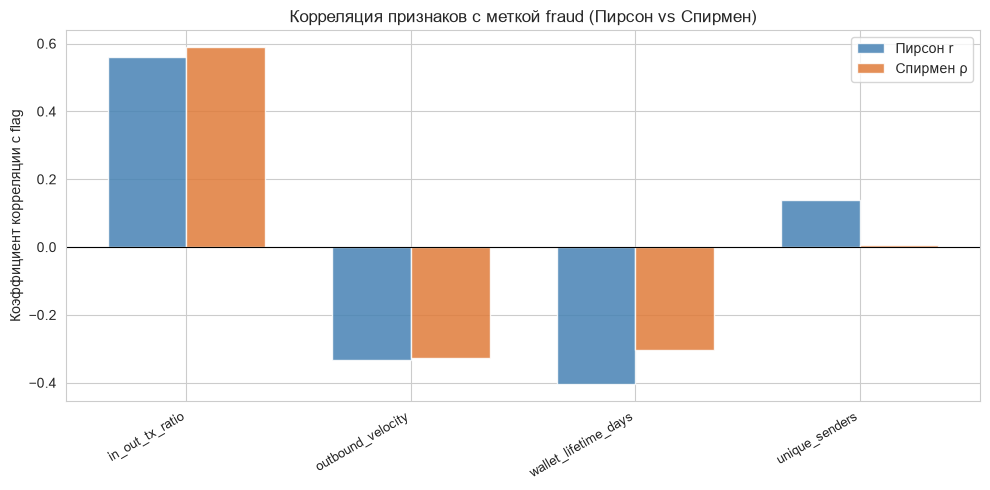

In [592]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(corr_df))
bar_w = 0.35

bars_p = ax.bar(x_pos - bar_w/2, corr_df["Пирсон r"],  width=bar_w, label="Пирсон r",  color="steelblue",  alpha=0.85)
bars_s = ax.bar(x_pos + bar_w/2, corr_df["Спирмен ρ"], width=bar_w, label="Спирмен ρ", color="#e07b39", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(corr_df["Признак"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Коэффициент корреляции с flag")
ax.set_title("Корреляция признаков с меткой fraud (Пирсон vs Спирмен)")
ax.legend()
plt.tight_layout()
plt.show()


#### Корреляционная матрица признаков

Смотрим связи **между признаками** (не с меткой). Если два столбца почти дублируют друг друга (высокая корреляция), модель получает одну и ту же информацию дважды — это **мультиколлинеарность**. Обычно порог для беспокойства — |ρ| > 0.7–0.8.


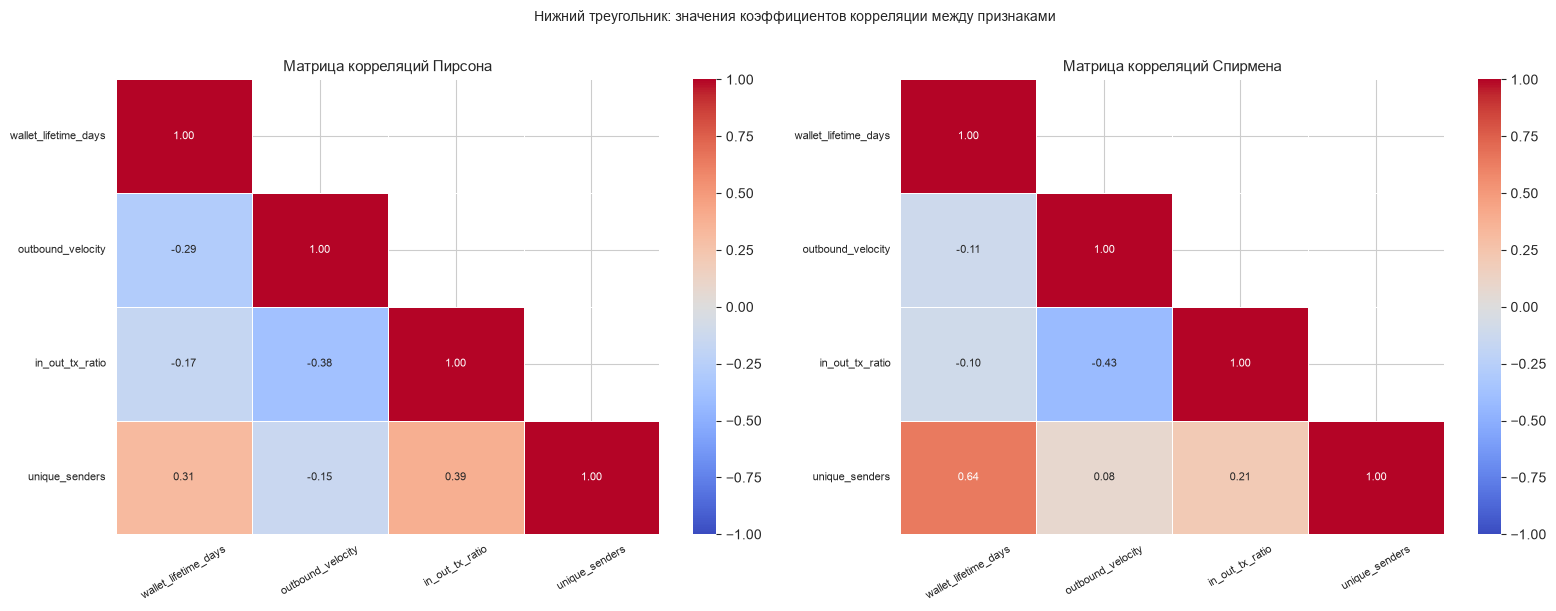

In [593]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method, title in zip(axes,
                               ["pearson",  "spearman"],
                               ["Матрица корреляций Пирсона", "Матрица корреляций Спирмена"]):
    matrix = kaggle_df[FEATURE_COLS].corr(method=method)
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    sns.heatmap(
        matrix, ax=ax, mask=mask,
        annot=True, fmt=".2f", cmap="coolwarm",
        vmin=-1, vmax=1, linewidths=0.5,
        annot_kws={"size": 8},
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Нижний треугольник: значения коэффициентов корреляции между признаками", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


**В наших данных:** максимум ρ ≈ 0.64 (между `wallet_lifetime_days` и `unique_senders`). Порог не достигнут — все 4 признака оставляем в модели.


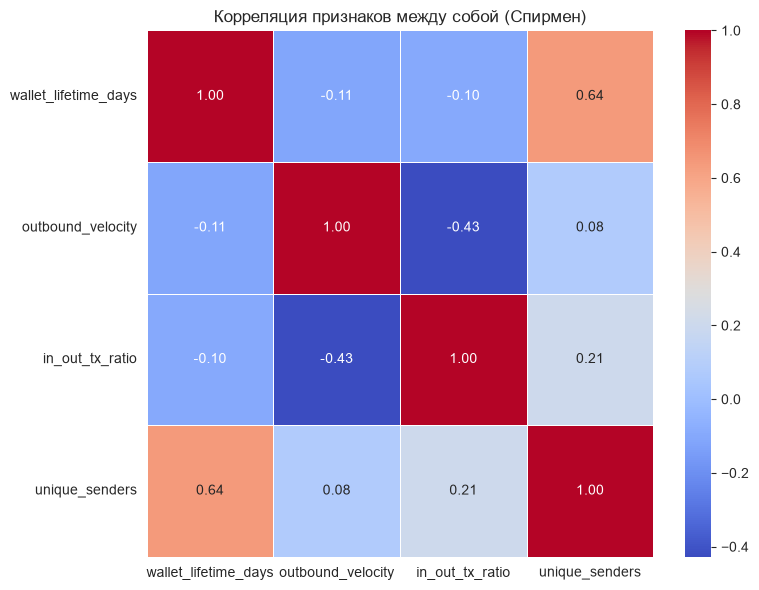

In [594]:
plt.figure(figsize=(8, 6))
corr_matrix = kaggle_df[FEATURE_COLS].corr(method='spearman')

sns.heatmap(
    corr_matrix, 
    annot=True,      
    cmap='coolwarm', 
    fmt=".2f",       
    linewidths=0.5
)

plt.title("Корреляция признаков между собой (Спирмен)")
plt.tight_layout()
plt.show()

### 4.2 Логистическая регрессия

**Идея модели:** по признакам кошелька оценить вероятность, что это fraud. Модель строит взвешенную сумму признаков и пропускает её через сигмоиду:

$$P(\text{fraud} \mid x) = \frac{1}{1 + e^{-z}}, \quad z = w_0 + w_1 x_1 + \ldots + w_n x_n$$

**Подготовка без утечки данных:**
1. Делим адреса на **train** (80%) и **test** (20%) **до** импутации и обработки выбросов (`prepare_modeling_split`).
2. Медианы для заполнения пропусков и границы винзоризации считаем **только по train**.
3. **Scaler** (`StandardScaler`) — приводит признаки к сопоставимому масштабу (среднее 0, дисперсия 1). Обучаем scaler **только на train**, к test применяем уже готовые параметры.

**Метрика для антифрода:** важен **Recall по fraud** — доля найденных мошенников среди всех fraud. Пропустить дроппера обычно хуже, чем ошибочно пометить обычный кошелёк.


In [595]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
)
from src.preprocessing import prepare_modeling_split, MODEL_FEATURE_COLS

train_df, test_df, preprocess_state = prepare_modeling_split(
    registry, KAGGLE_PATH, test_size=0.2, random_state=42
)

FEATURE_COLS = [c for c in MODEL_FEATURE_COLS if c in train_df.columns]
X_train = train_df[FEATURE_COLS].values
X_test = test_df[FEATURE_COLS].values
y_train = train_df["flag"].values
y_test = test_df["flag"].values

print(f"Train (обучающая): {len(train_df)}  |  Test (контрольная): {len(test_df)}")
print(f"Баланс классов (train): fraud={y_train.sum()}, legit={(y_train == 0).sum()}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Train (обучающая): 800  |  Test (контрольная): 200
Баланс классов (train): fraud=400, legit=400


In [596]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("Логистическая регрессия (test)")
print(classification_report(y_test, y_pred_lr, target_names=["legitimate", "fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")


Логистическая регрессия (test)
              precision    recall  f1-score   support

  legitimate       0.83      0.87      0.85       100
       fraud       0.86      0.82      0.84       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

ROC-AUC: 0.922


#### Коэффициенты модели

После масштабирования признаков коэффициенты можно сравнивать по величине:

- **Положительный коэффициент** → рост признака увеличивает вероятность fraud.
- **Отрицательный** → уменьшает.

Это не причинно-следственные связи, а вклад признака в **линейную** модель на нашей выборке.


,Признак,Коэффициент
0,wallet_lifetime_days,-2.0991
1,outbound_velocity,-1.0752
2,in_out_tx_ratio,1.0383
3,unique_senders,0.7902


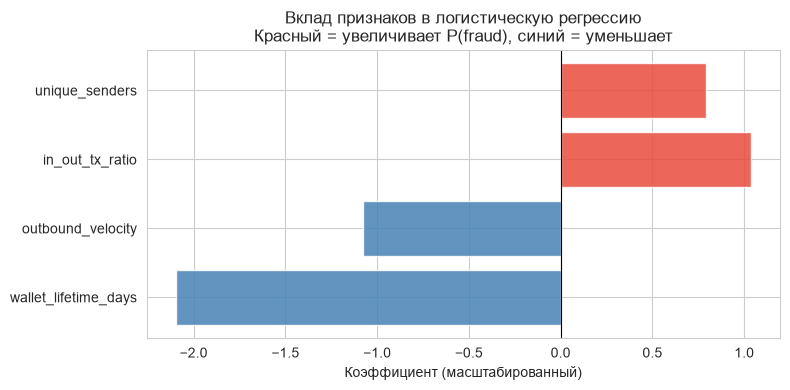

In [597]:
coef_df = (
    pd.DataFrame({"Признак": FEATURE_COLS, "Коэффициент": lr.coef_[0]})
    .sort_values("Коэффициент", key=abs, ascending=False)
)
display(coef_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c" if c > 0 else "steelblue" for c in coef_df["Коэффициент"]]
ax.barh(coef_df["Признак"], coef_df["Коэффициент"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Коэффициент (масштабированный)")
ax.set_title("Вклад признаков в логистическую регрессию\nКрасный = увеличивает P(fraud), синий = уменьшает")
plt.tight_layout()
plt.show()


#### Метрики на контрольной выборке (test)

| Метрика | Что показывает |
|---------|----------------|
| **Accuracy** | Доля всех верных ответов |
| **Precision** | Из помеченных как fraud — сколько действительно fraud |
| **Recall** | Из всех fraud — сколько модель нашла |
| **F1** | Баланс Precision и Recall |

Для поиска дропперов особенно смотрим **Recall по fraud**: пропустить мошенника хуже, чем выдать ложную тревогу по обычному кошельку.


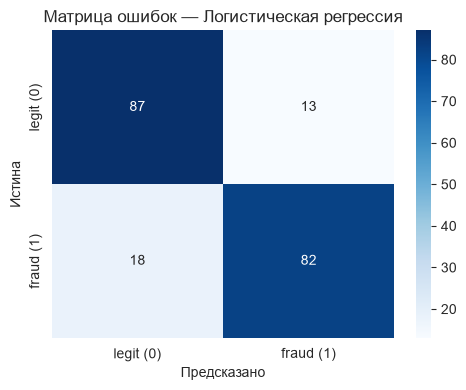

In [598]:
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["legit (0)", "fraud (1)"],
    yticklabels=["legit (0)", "fraud (1)"],
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Истина")
ax.set_title("Матрица ошибок — Логистическая регрессия")
plt.tight_layout()
plt.show()


### 4.3 Метод k ближайших соседей (KNN)

**Идея:** новый кошелёк сравниваем с уже размеченными. Смотрим **k** ближайших в пространстве признаков и голосуем: fraud или legitimate победило чаще — тот класс и предсказываем.

| k             | Поведение |
|---------------|-----------|
| Малое (1–3)   | Чувствительно к шуму, риск переобучения |
| Среднее (5–15) | Обычно разумный компромисс |
| Большое       | Сглаживает границы, риск недообучения |

Лучшее k = 14  (средний F1 на CV = 0.884)


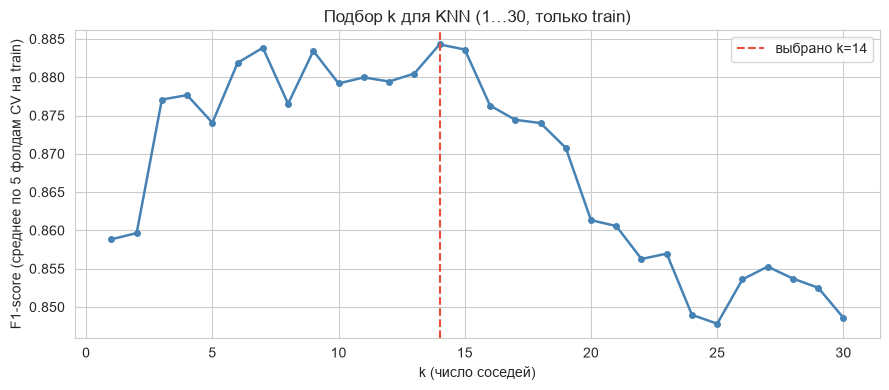

In [599]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

k_candidates = list(range(1, 31))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": k_candidates},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train_sc, y_train)
best_k = grid.best_params_["n_neighbors"]

print(f"Лучшее k = {best_k}  (средний F1 на CV = {grid.best_score_:.3f})")

cv_results_df = pd.DataFrame(grid.cv_results_)
cv_scores = (
    cv_results_df.groupby(cv_results_df["param_n_neighbors"].astype(int))["mean_test_score"]
    .first()
    .reset_index()
    .rename(columns={"param_n_neighbors": "k", "mean_test_score": "F1 (CV, mean)"})
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cv_scores["k"], cv_scores["F1 (CV, mean)"], marker="o", markersize=4, color="steelblue", linewidth=1.8)
ax.axvline(best_k, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"выбрано k={best_k}")
ax.set_xlabel("k (число соседей)")
ax.set_ylabel("F1-score (среднее по 5 фолдам CV на train)")
ax.set_title("Подбор k для KNN (1…30, только train)")
ax.legend()
plt.tight_layout()
plt.show()




In [600]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)

y_pred_knn  = knn.predict(X_test_sc)
y_proba_knn = knn.predict_proba(X_test_sc)[:, 1]

print(f"KNN (k={best_k}, контрольная выборка / test)")
print(classification_report(y_test, y_pred_knn, target_names=["legitimate", "fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_knn):.3f}")


KNN (k=14, контрольная выборка / test)
              precision    recall  f1-score   support

  legitimate       0.81      0.93      0.87       100
       fraud       0.92      0.78      0.84       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200

ROC-AUC: 0.944


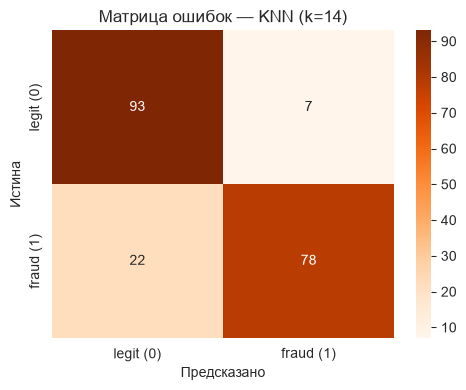

In [601]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["legit (0)", "fraud (1)"],
    yticklabels=["legit (0)", "fraud (1)"],
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Истина")
ax.set_title(f"Матрица ошибок — KNN (k={best_k})")
plt.tight_layout()
plt.show()


### 4.4 Сравнение моделей

Сводим метрики LogReg и KNN в одну таблицу и строим **ROC-кривые**.

**ROC-кривая** показывает компромисс при разных порогах отсечения:
- **TPR (Recall)** — какую долю fraud модель находит;
- **FPR** — какую долю legitimate ошибочно помечает как fraud.

**AUC** (площадь под кривой): 0.5 — как случайное угадывание, 1.0 — идеальное разделение классов. Чем выше AUC, тем лучше модель ранжирует «подозрительные» адреса выше обычных.


In [602]:
from sklearn.metrics import roc_curve

comparison = pd.DataFrame({
    "Модель": ["Логистическая регрессия", f"KNN (k={best_k})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
    ],
    "Precision (fraud)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
    ],
    "Recall (fraud)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
    ],
    "F1 (fraud)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_knn),
    ],
}).round(3)

display(comparison)


,Модель,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
0,Логистическая регрессия,0.845,0.863,0.82,0.841,0.922
1,KNN (k=14),0.855,0.918,0.78,0.843,0.944


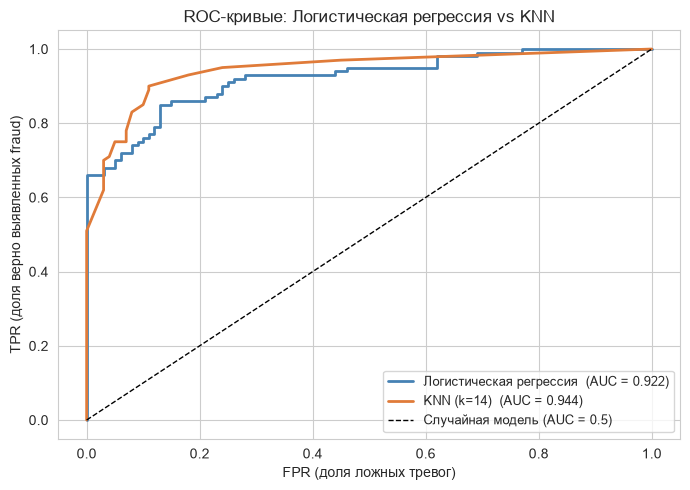

In [603]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_proba, color in [
    ("Логистическая регрессия", y_proba_lr,  "steelblue"),
    (f"KNN (k={best_k})",       y_proba_knn, "#e07b39"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Случайная модель (AUC = 0.5)")
ax.set_xlabel("FPR (доля ложных тревог)")
ax.set_ylabel("TPR (доля верно выявленных fraud)")
ax.set_title("ROC-кривые: Логистическая регрессия vs KNN")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 4.5 Итоги этапа 4

**Корреляции (4.1).** Сильнее всего с fraud связаны `wallet_lifetime_days` и `in_out_tx_ratio` — согласуется с H1 и H3. Для скошенных данных надёжнее Спирмен.

**Модели (4.2–4.4).** Предобработка и scaler — только по train; k подбирается CV на train (перебор 1…30). LogReg и KNN дают сопоставимое качество (F1 порядка 0.84–0.87 на test).

**Итог по проекту**

На подвыборке Kaggle (1000 адресов) статистически подтверждены короткий срок жизни, высокое соотношение входящих/исходящих и эффект «много отправителей». Простые модели разделяют классы с приемлемым качеством.

**Ограничения:** только агрегаты Ethereum из Kaggle; выводы нельзя без проверки переносить на другие сети и свежие данные без переобучения.
